In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import shap
import joblib
import json
import importlib

import src.preprocess, src.cluster
importlib.reload(src.preprocess)
importlib.reload(src.cluster)

from src.preprocess import load_raw, engineer_features, encode_and_split
from src.cluster import cluster_on_shap
from src.model import load_model

# Rebuild full dataset
raw        = load_raw(PROJECT_ROOT / 'data/DataCoSupplyChainDataset.csv')
engineered = engineer_features(raw)

# We need the string version (before encoding) for cluster profiles
# engineer_features keeps string columns intact — this is our string df
engineered_strings = engineered.copy()

# Now encode for model prediction
X_train, X_test, y_train, y_test, feat_names, encoders = encode_and_split(
    engineered, target_col='Late_delivery_risk', test_year=2017
)

print(f'engineered_strings shape: {engineered_strings.shape}')
print(f'feat_names count: {len(feat_names)}')

d:\Supply Guard AI\supplyguard\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


engineered_strings shape: (180519, 38)
feat_names count: 37


In [2]:
model    = load_model(PROJECT_ROOT / 'models/xgb_model.pkl')
explainer = joblib.load(PROJECT_ROOT / 'models/shap_explainer.pkl')

# Need encoded version of ALL rows (not just train/test split)
# encode_and_split splits but we need full X — rebuild without splitting
from sklearn.preprocessing import LabelEncoder

df_full = engineered.copy()
df_full.drop(columns=['Late_delivery_risk'], inplace=True, errors='ignore')

enc = {}
for col in df_full.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col].astype(str))
    enc[col] = le

df_full.fillna(df_full.median(numeric_only=True), inplace=True)
X_full_encoded = df_full.values

print(f'X_full_encoded shape: {X_full_encoded.shape}')

# Predict risk for all rows
y_prob_full = model.predict_proba(X_full_encoded)[:, 1]
print(f'High risk orders (>0.6): {(y_prob_full > 0.6).sum()}')

# SHAP for all rows — batched for memory safety
chunk_size = 10000
shap_chunks = []
for i in range(0, len(X_full_encoded), chunk_size):
    chunk = X_full_encoded[i : i + chunk_size]
    shap_chunks.append(explainer.shap_values(chunk))
    print(f'  SHAP computed: rows {i} to {min(i+chunk_size, len(X_full_encoded))}')

shap_values = np.vstack(shap_chunks)
print(f'SHAP matrix shape: {shap_values.shape}')

X_full_encoded shape: (180519, 37)
High risk orders (>0.6): 61600
  SHAP computed: rows 0 to 10000
  SHAP computed: rows 10000 to 20000
  SHAP computed: rows 20000 to 30000
  SHAP computed: rows 30000 to 40000
  SHAP computed: rows 40000 to 50000
  SHAP computed: rows 50000 to 60000
  SHAP computed: rows 60000 to 70000
  SHAP computed: rows 70000 to 80000
  SHAP computed: rows 80000 to 90000
  SHAP computed: rows 90000 to 100000
  SHAP computed: rows 100000 to 110000
  SHAP computed: rows 110000 to 120000
  SHAP computed: rows 120000 to 130000
  SHAP computed: rows 130000 to 140000
  SHAP computed: rows 140000 to 150000
  SHAP computed: rows 150000 to 160000
  SHAP computed: rows 160000 to 170000
  SHAP computed: rows 170000 to 180000
  SHAP computed: rows 180000 to 180519
SHAP matrix shape: (180519, 37)


High-risk orders: 61600 (34.1% of total)


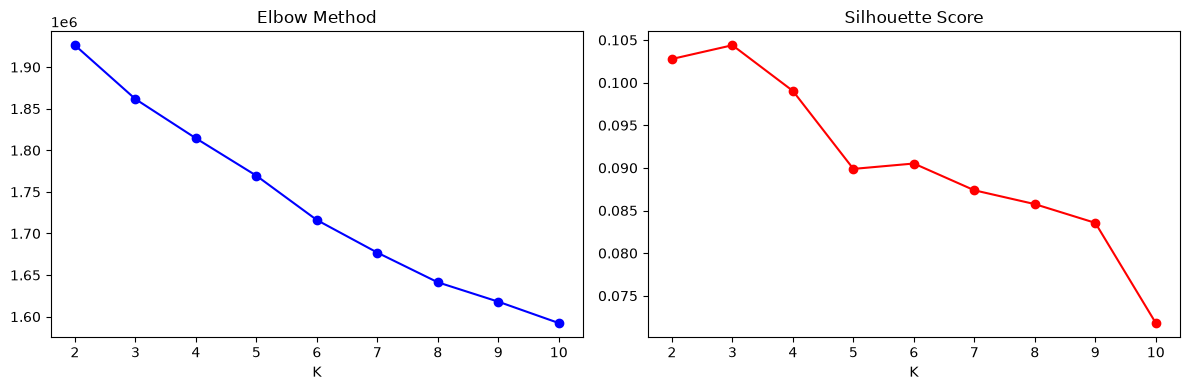

Best K by silhouette: 3
  Cluster 0: 34945 orders | Risk driver: Days for shipment (scheduled) (SHAP=1.090000033378601) | Region: Western Europe | Mode: Second Class
  Cluster 1: 26435 orders | Risk driver: Shipping Mode (SHAP=6.3383002281188965) | Region: Central America | Mode: First Class
  Cluster 2: 220 orders | Risk driver: Shipping Mode (SHAP=2.289599895477295) | Region: Central America | Mode: Second Class
   cluster_id  order_count          dominant_shap_feature  dominant_region  \
0           0        34945  Days for shipment (scheduled)   Western Europe   
1           1        26435                  Shipping Mode  Central America   
2           2          220                  Shipping Mode  Central America   

  dominant_shipping_mode  profit_at_risk  
0           Second Class       721963.82  
1            First Class       615242.81  
2           Second Class         3347.18  


In [7]:
# engineered_strings still has original string values like 'First Class', 'Western Europe'
# We need to drop the target from it first
engineered_strings_notarget = engineered_strings.drop(
    columns=['Late_delivery_risk'], errors='ignore'
)

high_risk_df, cluster_profiles = cluster_on_shap(
    engineered_strings_notarget,
    shap_values,
    feat_names,
    y_prob_full,
    risk_threshold=0.6,
    k=None   # auto-select via silhouette
)

print(cluster_profiles[['cluster_id', 'order_count', 'dominant_shap_feature',
                          'dominant_region', 'dominant_shipping_mode', 'profit_at_risk']])

In [8]:
cluster_profiles.to_csv(PROJECT_ROOT / 'data/cluster_profiles.csv', index=False)
high_risk_df.to_csv(PROJECT_ROOT / 'data/high_risk_orders.csv', index=False)
np.save(PROJECT_ROOT / 'models/shap_values_full.npy', shap_values)

print('Saved:')
print('  data/cluster_profiles.csv')
print('  data/high_risk_orders.csv')
print('  models/shap_values_full.npy')

Saved:
  data/cluster_profiles.csv
  data/high_risk_orders.csv
  models/shap_values_full.npy
